In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from utils import *
sns.set()

In [2]:
p = np.array([1, 1])
q = np.array([1, -1])

In [3]:
w0 = np.array([1 + np.log(2), 1 - np.log(2)])

beta = 0.9
a = (1-beta) / (1+beta)
c = a / 2
print(2 * c)

max_iter = 5000 #int(1e4)

0.05263157894736841


# Sign subgradient descent with momentum

**Algorithm**
$\alpha_t = \frac{1}{t+1}$
| Step | Operation |
|------|-----------|
| Init | $M_0 = 0$|
| **for** $t = 0, 1, \dots, T-1$ | |
| 1 | $G_t \in \partial f(W_t)$ |
| 2 | $M_t = \beta M_t + (1-\beta) G_t$ |
| 3 | $W_{t+1} = W_t - \alpha_t\mathrm{LMO}_{\|\cdot\|}(M_t)$ | 

In [4]:
w_muon, logging_muon = sign_subgradient_descent_momentum(w0=w0, c=c, p=p, q=q, s=0, max_iters=max_iter, beta=beta)
ws_muon = np.array(logging_muon["w"])

In [5]:
w_ef_muon, logging_ef_muon = sign_subgradient_descent_ef_momentum(w0=w0, c=c, p=p, q=q, beta=beta, s=0, max_iters=max_iter, 
                                                  fixed_gamma=False)
ws_ef_muon = np.array(logging_ef_muon["w"])

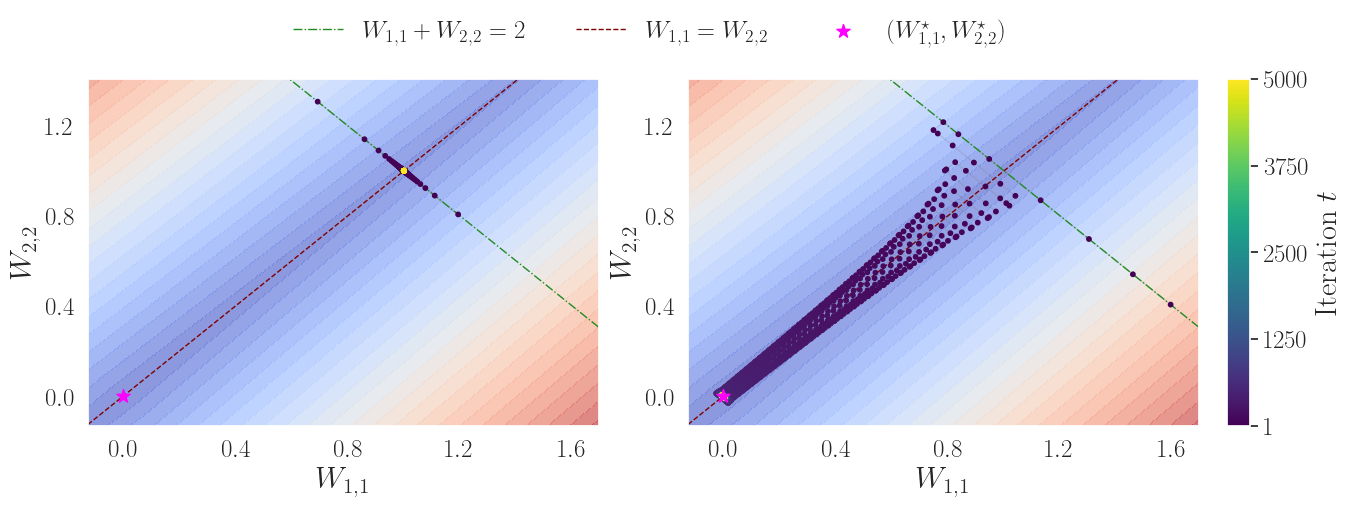

In [6]:
experiment_name = "countex_muon_ef_muon"
plot_trajectory_side_by_side(
    ws_muon, ws_ef_muon, w0, c,
    n_show=max_iter,
    # titles=("Muon", "EF-Muon"),
    filename=experiment_name,
)
